# Examples using the REST-based interface to *AgroDataCube*

**Note:** All examples are currently based on the *AgroDataCube* [Postman documentation for V2.1](https://documenter.getpostman.com/view/3284162/TVeqd7aa).

**Author:** Bruno Marcos

**Created in:** February 19, 2026

**Last modified in:** March 23, 2026

## Settings

In [94]:
# Load packages
library(httr)
library(jsonlite)
library(geojsonio)
library(terra)
library(rNDC)

# Define parameters
mytoken <- Sys.getenv("ADC_TOKEN") # (replace by your own token)
mypolygon1 <- "POLYGON((4.2 52, 4.2 53, 4.3 53, 4.3 52, 4.2 52))"
mypolygon2 <- "POLYGON((219478 481588.256000001,219478 497638.432,237339.072000001 497638.432,237339.072000001 481588.256000001,219478 481588.256000001))"
mypolygon3 <- "POLYGON((175742 445233,175742 446118,177050 446118,177050 445233,175742 445233))"

## 1. Fields

Requests to retrieve data from the crop registration datasets, see [RVO](https://www.rvo.nl/) website. Several years of crop registrations are available in the Cube. Crop fields change per year, and are recorded by farmers with an indication of the crop that will be grown on the field. The geometries of the fields are provided as-is, and might contain geometric anomalies.

Once the ID of a specific field is known, it can be used to request addition and detailed information for that particular field:

In [95]:
myurl <- adc_url(option = "Fields",
                 params = c(geometry = mypolygon1,
                            epsg = "4326",
                            year = 2016,
                            cropname = "mais",
                            output_epsg = "4326"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/fields?geometry=POLYGON((4.2%2052,%204.2%2053,%204.3%2053,%204.3%2052,%204.2%2052))&epsg=4326&year=2016&cropname=mais&output_epsg=4326

In [96]:
myres <- adc_get(url = myurl, token = mytoken)
myres_sf <- myres |>
  toJSON(auto_unbox = TRUE) |>
  geojson_sf()
print(myres_sf)

Simple feature collection with 5 features and 7 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 4.2 ymin: 52 xmax: 4.2925 ymax: 52.0048
Geodetic CRS:  WGS 84
       area grondgebruik crop_code year   crop_name perimeter fieldid
1 18907.379     Bouwland       259 2016 Mais, snij-   589.857 5871107
2 17417.011     Bouwland       259 2016 Mais, snij-   564.305 6121295
3  7040.033     Bouwland       259 2016 Mais, snij-   362.238 5552695
4   594.969     Bouwland       259 2016 Mais, snij-   120.783 5748120
5    10.986     Bouwland       259 2016 Mais, snij-    15.796 6155689
                        geometry
1 POLYGON ((4.2905 52.0001, 4...
2 POLYGON ((4.2867 52, 4.2849...
3 POLYGON ((4.2779 52, 4.2762...
4 POLYGON ((4.2759 52.0002, 4...
5 POLYGON ((4.2001 52.0048, 4...


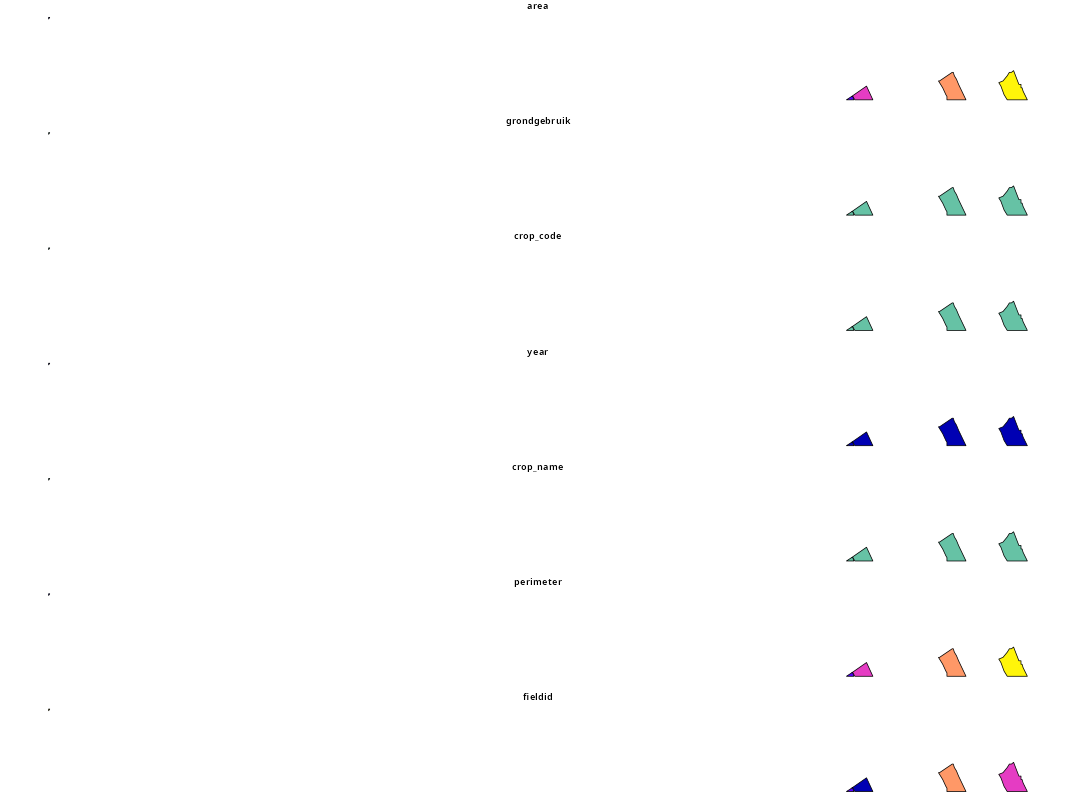

In [97]:
plot(myres_sf)

### 1.1. Retrieve the geometry and crop information of the intersections of the supplied geometry and the fields

In [98]:
myurl <- adc_url(option = "Fields",
                 params = c(geometry = mypolygon2,
                            fieldid = "9403114",
                            epsg = "28992",
                            output_epsg = "4326",
                            year = 2016,
                            cropcode = "265",
                            cropname = "mais",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/fields?geometry=POLYGON((219478%20481588.256000001,219478%20497638.432,237339.072000001%20497638.432,237339.072000001%20481588.256000001,219478%20481588.256000001))&fieldid=9403114&epsg=28992&output_epsg=4326&year=2016&cropcode=265&cropname=mais&page_size=25&page_offset=0

In [99]:
myres <- adc_get(url = myurl, token = mytoken)
myres_df <- myres|>
  toJSON() |>
  fromJSON(simplifyDataFrame = TRUE)
myres_df$metadata |>
  head(5) |>
  print()

  column_name
1        area
2   crop_code
3   crop_name
4     fieldid
5        geom
                                                                             description units
1                                                                     Area of a geometry    m2
2                                                   Code for the crop as supplied by RVO  NULL
3 Name of the crop as supplied by RVO. For AgroDataCube harmonized over different years.  NULL
4                   Unique id of a parcel in the AgroDataCube unique per parcel per year  NULL
5 The geometry of an object or intersection depending on the resource and the parameters  NULL


### 1.2. Retrieve the geometry and crop information for a specific crop field

In [100]:
myurl <- adc_url(option = "Fields",
                 params = c(geometry = mypolygon2,
                            fieldid = "9403114",
                            output_epsg = "4326",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/fields?geometry=POLYGON((219478%20481588.256000001,219478%20497638.432,237339.072000001%20497638.432,237339.072000001%20481588.256000001,219478%20481588.256000001))&fieldid=9403114&output_epsg=4326&page_offset=0

In [101]:
myres <- adc_get(url = myurl, token = mytoken)
myres_df <- myres |>
  toJSON() |>
  fromJSON(simplifyDataFrame = TRUE)
myres_df$metadata|>
  head(5) |>
  print()

  column_name
1        area
2   crop_code
3   crop_name
4     fieldid
5        geom
                                                                             description units
1                                                                     Area of a geometry    m2
2                                                   Code for the crop as supplied by RVO  NULL
3 Name of the crop as supplied by RVO. For AgroDataCube harmonized over different years.  NULL
4                   Unique id of a parcel in the AgroDataCube unique per parcel per year  NULL
5 The geometry of an object or intersection depending on the resource and the parameters  NULL


## 2. Altitude (AHN)

This contains requests to retrieve AHN (‘Actueel Hoogtebestand Nederland’) data. AHN is provided as Open Data by Rijkswaterstaat.

As of december 2022 AHN2 has been replaced by AHN3.

For more details please see: [Rijkswaterstaat website AHN](https://www.rijkswaterstaat.nl/zakelijk/open-data/actueel-hoogtebestand-nederland/)

### 2.1. Altitude zonal statistics for supplied geometry

In [102]:
myurl <- adc_url(option = "AHN",
                 params = c(geometry = mypolygon1,
                            epsg = "4326"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/ahn?geometry=POLYGON((4.2%2052,%204.2%2053,%204.3%2053,%204.3%2052,%204.2%2052))&epsg=4326

In [103]:
myres <- adc_get(url = myurl, token = mytoken)
myres_df <- myres |>
  toJSON() |>
  fromJSON(simplifyDataFrame = TRUE)
myres_df$features$properties |>
  unlist() |>
  print()

       area         min         max        mean 
755607361.1      -534.9      3364.6       166.6 


### 2.2. Raster data geotiff for AHN (ahn_image)

In [104]:
myurl <- adc_url(option = "AHN_image",
                 params = c(geometry = mypolygon1,
                            epsg = "4326",
                            output_epsg = "4326"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/ahn_image?geometry=POLYGON((4.2%2052,%204.2%2053,%204.3%2053,%204.3%2052,%204.2%2052))&epsg=4326&output_epsg=4326

In [105]:
myres <- adc_get(url = myurl, token = mytoken)
myres |>
  unlist() |>
  cat()

Geometry area (m2) 950792200 exceeds limit of 100000000

In [106]:
myres <- adc_get(option = "AHN_image",
                 params = c(geometry = mypolygon1,
                            epsg = "4326",
                            output_epsg = "4326"),
                 token = mytoken,
                 server = "adc",
                 download = TRUE)
myres |>
  unlist() |>
  cat()

Geometry area (m2) 950792200 exceeds limit of 100000000

## 3. Meteo

Requests to retrieve information about ánd from the KNMI (the Royal Netherlands Meteorological Institute) weather stations for which data has been stored in the Cube. This data is provided as Open Data by KNMI, see: <https://data.knmi.nl/>.

Once the ID of a meteostation has been retrieved it can be used to request further details and the weather observations of that particular station.

### 3.1. Return a list of all meteostations for which data is available

In [107]:
myurl <- adc_url(option = "Meteo_stations",
                 params = c(output_epsg = "4326",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/meteostations?output_epsg=4326&page_size=25&page_offset=0

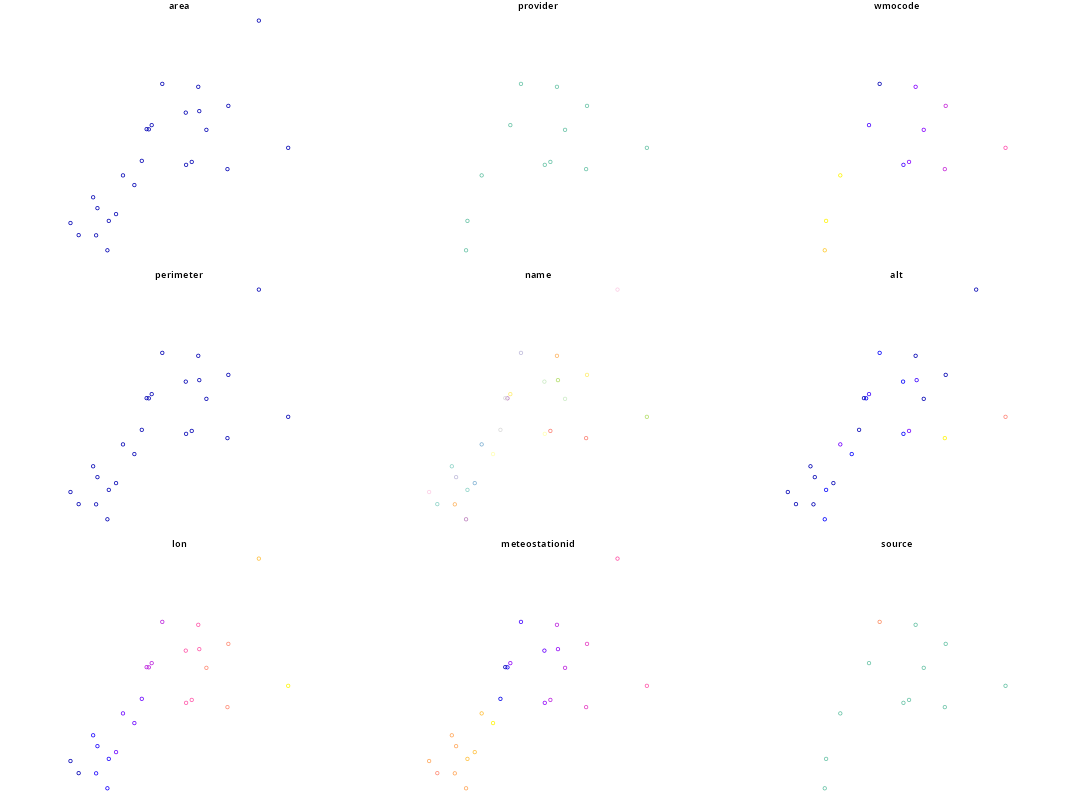

Warning message:
plotting the first 9 out of 10 attributes; use max.plot = 10 to plot all 


In [108]:
myres <- adc_get(url = myurl, token = mytoken)
myres_sf <- myres |>
  toJSON(auto_unbox = TRUE) |>
  geojson_sf()
plot(myres_sf)

### 3.2. Return the data for the given meteostation

In [109]:
myurl <- adc_url(option = "Meteo_stations",
                 params = c(output_epsg = "4326",
                            meteostation = "330",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/meteostations/330?output_epsg=4326&page_size=25&page_offset=0

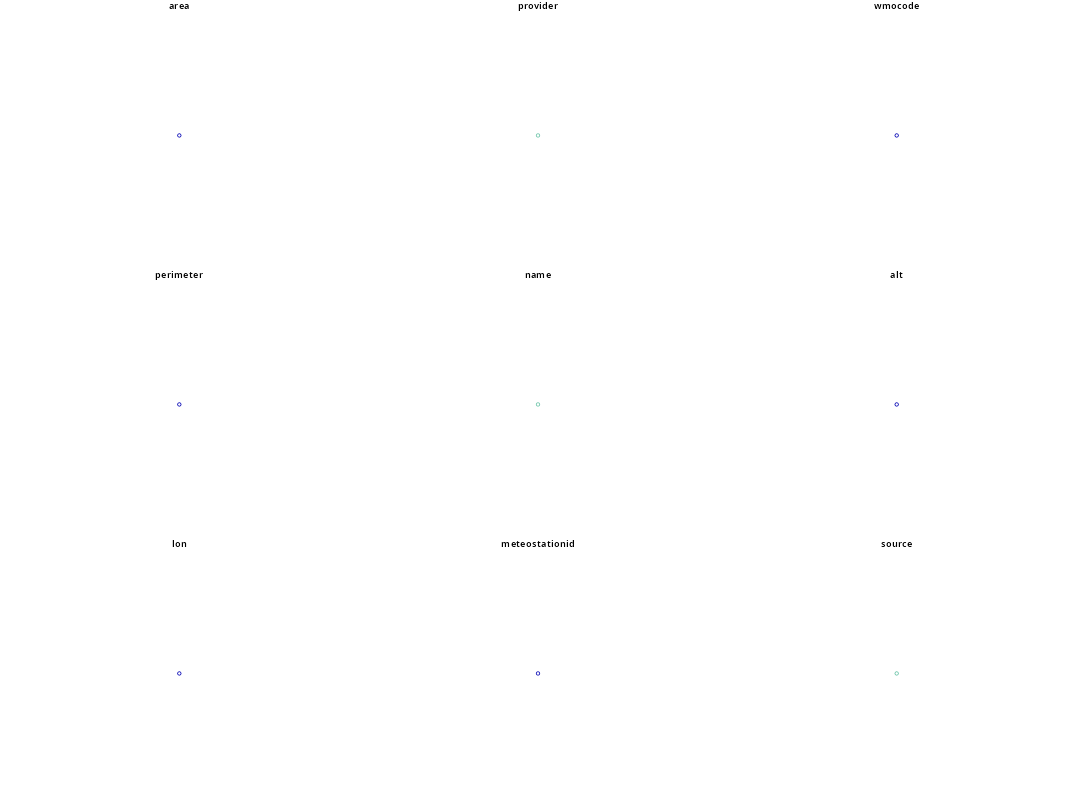

Warning message:
plotting the first 9 out of 10 attributes; use max.plot = 10 to plot all 


In [110]:
myres <- adc_get(url = myurl, token = mytoken)
myres_sf <- myres |>
  toJSON(auto_unbox = TRUE) |>
  geojson_sf()
plot(myres_sf)

### 3.3. Retrieve weather data from one of the meteostations and for a specific date

In [111]:
myurl <- adc_url(option = "Meteo_data",
                 params = c(output_epsg = "4326",
                            stationid = "210",
                            date = "20160101",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/meteodata?output_epsg=4326&stationid=210&date=20160101&page_size=25&page_offset=0

In [112]:
myres <- adc_get(url = myurl, token = mytoken)
myres_df <- myres |>
  toJSON() |>
  fromJSON(simplifyDataFrame = TRUE)
cat("Length:", length(myres_df$features$properties), "values")

Length: 20 values

In [113]:
t(myres_df$features$properties) |>
  as.data.frame() |>
  setNames("value") |>
  print()

                                        value
meteostationid                            210
datum                              2016-01-01
mean_temperature                          5.6
min_temperature                           1.1
max_temperature                           8.3
sunshine_duration                         4.1
global_radiation                          300
precipitation                             1.1
mean_sea_level_pressure                1021.2
mean_humidity                              91
max_humidity                              100
potential_evapotranspiration              0.4
vector_mean_windspeed                     2.7
daily_mean_windspeed                      3.9
max_hourly_mean_windspeed                   7
hourly_division_max_windspeed              23
min_hourly_mean_windspeed                   1
hourly_division_min_windspeed               4
max_gust_windspeed                         11
hourly_division_max_gust_windspeed         22


### 3.4. Retrieve weather data from one of the meteostations for a specified time period

In [114]:
myurl <- adc_url(option = "Meteo_data",
                 params = c(output_epsg = "4326",
                            meteostation = "330",
                            fromdate = "20160101",
                            todate = "20251231",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/meteodata?output_epsg=4326&meteostation=330&fromdate=20160101&todate=20251231&page_size=25&page_offset=0

In [115]:
myres <- adc_get(url = myurl, token = mytoken)
myres_df <- myres |>
  toJSON() |>
  fromJSON(simplifyDataFrame = TRUE)
cat("Dimensions:",
    nrow(myres_df$features$properties), "rows x",
    ncol(myres_df$features$properties), "columns")

Dimensions: 25 rows x 20 columns

In [116]:
myres_df$features$properties |>
  as.data.frame() |>
  head(3) |>
  print()

  meteostationid      datum mean_temperature min_temperature max_temperature sunshine_duration
1            330 2016-01-01              6.6             2.8               9               3.5
2            330 2016-01-02              7.2             5.2             9.3               0.8
3            330 2016-01-03              7.1             4.6             8.9                 0
  global_radiation precipitation mean_sea_level_pressure mean_humidity max_humidity
1              282             0                  1020.8            87           95
2              147           9.8                  1006.6            91           98
3              191          15.7                     997            90           97
  potential_evapotranspiration vector_mean_windspeed daily_mean_windspeed
1                          0.4                   3.9                  6.4
2                          0.2                  10.1                 10.3
3                          0.3                  10.3          

## 4. Soil

Requests to retrieve data about soil conditions from the BOFEK 2012 datasets ánd the Dutch soil map 1:50.000 (2014).

“BOFEK 2012”: This is a rather complex but interesting dataset derived from the soil map of the Netherlands. It contains a classification in 72 categories of soil characteristics, and is for example used as input for simulation models.

The dataset is created and provided by WUR. For more information please see <https://www.wur.nl/nl/show/Bodemfysische-Eenhedenkaart-BOFEK2012.htm>.

A soilparamid (soil parameter ID) is needed to request the data. It can be retrieved for a particular field, once the ID of the field is known. Please see the Fields requests.

“Dutch soil map 1:50.000”: This dataset is provided by WUR, and also avaible as Open Data. For more information please see <https://www.wur.nl/nl/show/Bodemkaart-1-50-000.htm>.

### 4.1. Return all the information for the given `soilparamid`

In [117]:
myurl <- adc_url(option = "Soilparams",
                 params = c(soilparamid = "101",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/soilparams?soilparamid=101&page_size=25&page_offset=0

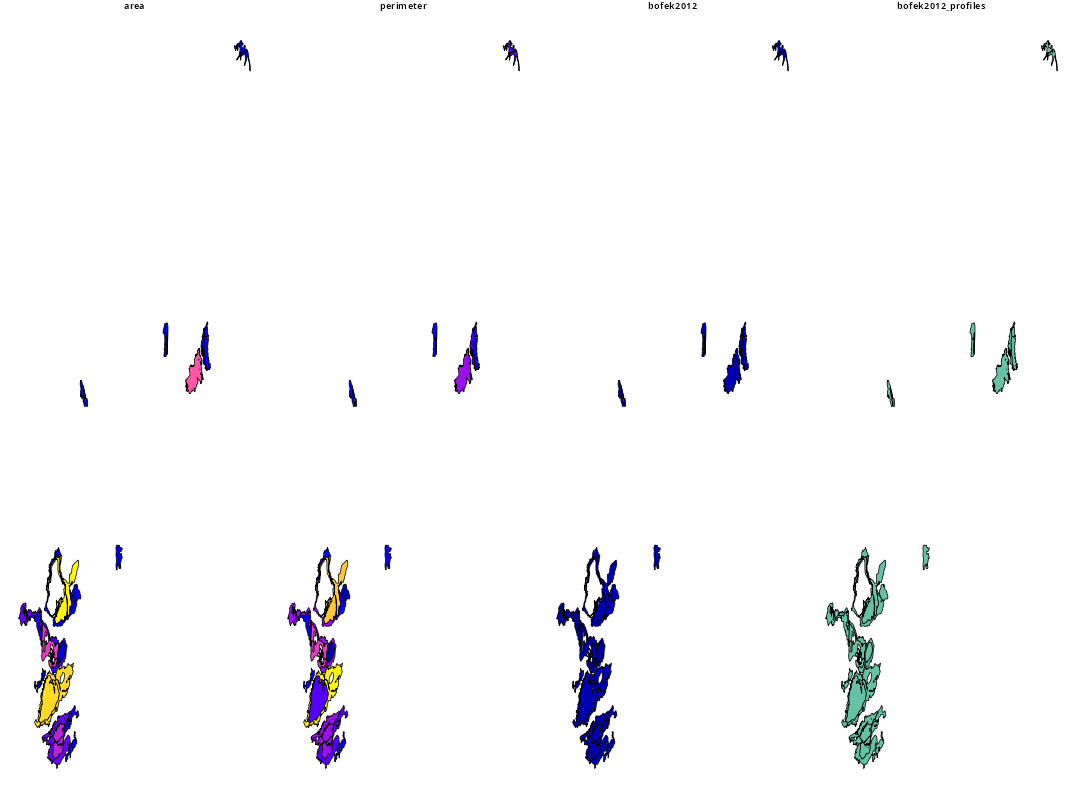

In [118]:
myres <- adc_get(url = myurl, token = mytoken)
myres_sf <- myres |>
  toJSON(auto_unbox = TRUE) |>
  geojson_sf()
suppressWarnings(plot(myres_sf))

### 4.2. Return the intersections of the supplied `geometry` and soilmap

In [119]:
myurl <- adc_url(option = "Soiltypes",
                 params = c(geometry = mypolygon1,
                            epsg = "4326",
                            output_epsg = "4326",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/soiltypes?geometry=POLYGON((4.2%2052,%204.2%2053,%204.3%2053,%204.3%2052,%204.2%2052))&epsg=4326&output_epsg=4326&page_size=25&page_offset=0

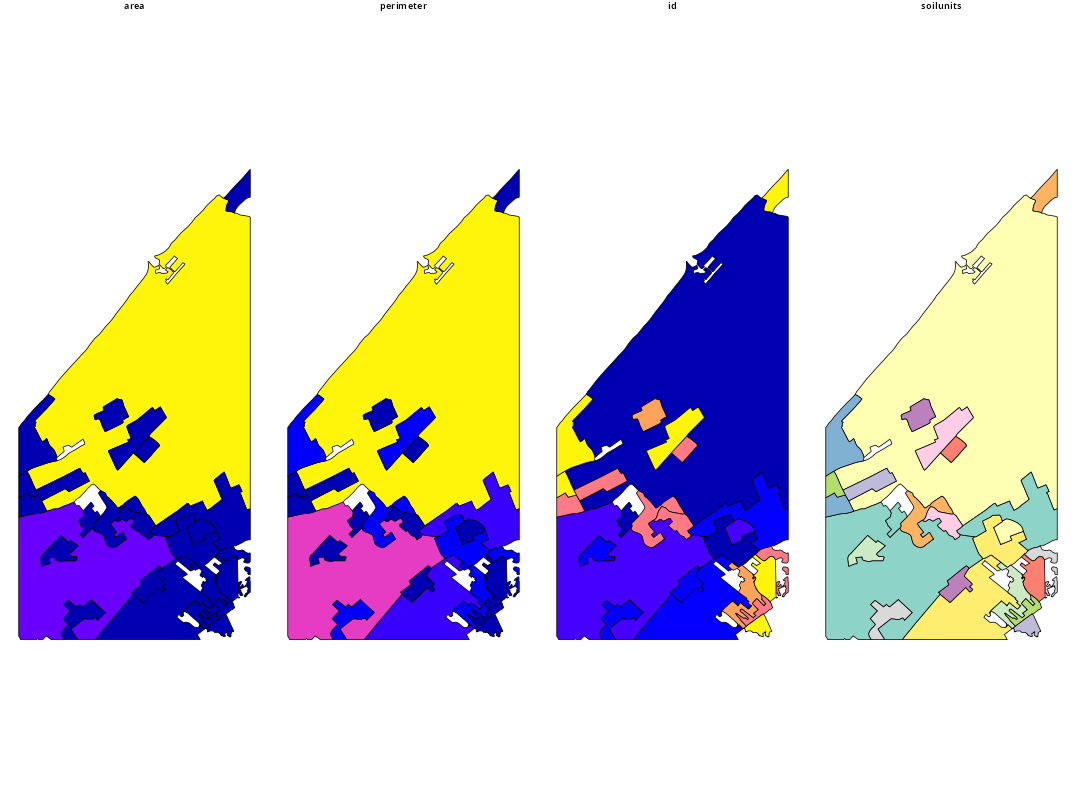

In [120]:
myres <- adc_get(url = myurl, token = mytoken)
myres_sf <- myres |>
  toJSON(auto_unbox = TRUE) |>
  geojson_sf()
plot(myres_sf)

### 4.3. Return all the information for the given soilmap `entityid`

In [121]:
myurl <- adc_url(option = "Soiltypes",
                 params = c(entityid = "49100",
                            output_epsg = "4326",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/soiltypes?entityid=49100&output_epsg=4326&page_size=25&page_offset=0

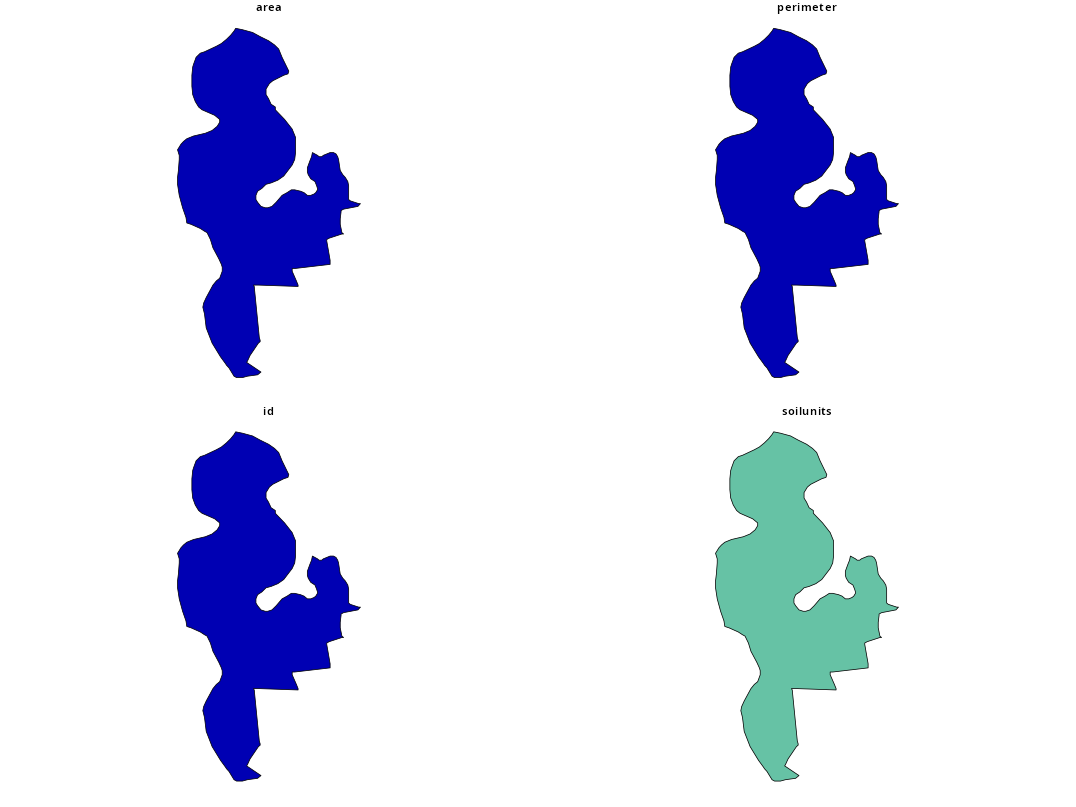

In [122]:
myres <- adc_get(url = myurl, token = mytoken)
myres_sf <- myres |>
  toJSON(auto_unbox = TRUE) |>
  geojson_sf()
plot(myres_sf)

## 5. Vegetation (NDVI)

NDVI (Normalized Difference Vegetation Index)

### 5.1. NDVI statistics

In [123]:
myurl <- adc_url(option = "NDVI",
                 params = c(geometry = mypolygon2,
                            date = "20191110",
                            epsg = "28992",
                            output_epsg = "4326"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/ndvi?geometry=POLYGON((219478%20481588.256000001,219478%20497638.432,237339.072000001%20497638.432,237339.072000001%20481588.256000001,219478%20481588.256000001))&date=20191110&epsg=28992&output_epsg=4326

In [124]:
myres <- adc_get(url = myurl, token = mytoken)
myres_df <- myres |>
  toJSON() |>
  fromJSON(simplifyDataFrame = TRUE)
cat("Dimensions:",
    nrow(myres_df$features$properties), "rows x",
    ncol(myres_df$features$properties), "columns")

Dimensions: 50 rows x 5 columns

In [125]:
myres_df$features$properties |>
  head(10) |>
  print()

        datum ndvi_stddev ndvi_avg fieldid daynr
1  2019-11-10       0.116    0.584 8586606   314
2  2019-11-10      0.0575   0.4804 8586630   314
3  2019-11-10           0    0.532 8586877   314
4  2019-11-10       0.004    0.832 8587020   314
5  2019-11-10           0    0.664 8587122   314
6  2019-11-10       0.021   0.8344 8587413   314
7  2019-11-10           0    0.796 8587591   314
8  2019-11-10      0.0337   0.7697 8587728   314
9  2019-11-10           0    0.608 8587833   314
10 2019-11-10      0.0234   0.8247 8587906   314


### 5.2. Raster data geotiff for NDVI (ndvi_image)

In [126]:
myurl <- adc_url(option = "NDVI_image",
                 params = c(geometry = mypolygon2,
                            date = "20191110",
                            epsg = "28992",
                            output_epsg = "4326"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/ndvi_image?geometry=POLYGON((219478%20481588.256000001,219478%20497638.432,237339.072000001%20497638.432,237339.072000001%20481588.256000001,219478%20481588.256000001))&date=20191110&epsg=28992&output_epsg=4326

In [127]:
myres <- adc_get(url = myurl, token = mytoken)
myres |>
  unlist() |>
  cat()

Geometry area (m2) 286673349 exceeds limit of 100000000

## 6. Codes

Requests to retrieve more details about a specific crop or soil code returned by other requests. These are the code lists as used in the original datasets, e.g. in the crop registration and the soil map.

### 6.1. Retrieve a list of all possible cropcodes

In [128]:
myurl <- adc_url(option = "Cropcodes",
                 params = c(page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/codes/cropcodes?page_size=25&page_offset=0

In [129]:
myres <- adc_get(url = myurl, token = mytoken)
myres_df <- myres |>
  toJSON() |> 
  fromJSON(simplifyDataFrame = TRUE)
cat("Dimensions:",
    nrow(myres_df$features$properties), "rows x",
    ncol(myres_df$features$properties), "columns")

Dimensions: 25 rows x 7 columns

In [130]:
myres_df$features$properties |>
  head(4) |>
  print()

  cropcode           cropname grondgebruik cropid conflict standard_revenue comment
1     7137      Bonen, overig     Bouwland    570    FALSE             NULL    NULL
2     7138           Palmkool     Bouwland    571    FALSE             NULL    NULL
3     7127           Rietland      Overige    563    FALSE             NULL    NULL
4     7128 Rietkraag/rietzoom      Overige    564    FALSE             NULL    NULL


### 6.2. Retrieve details for a specific cropcode

In [131]:
myurl <- adc_url(option = "Cropcodes",
                 params = c(cropcode = "265",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/codes/cropcodes?cropcode=265&page_size=25&page_offset=0

In [132]:
myres <- adc_get(url = myurl, token = mytoken)
myres_df <- myres |>
  toJSON() |>
  fromJSON(simplifyDataFrame = TRUE)
cat("Dimensions:",
    nrow(myres_df$features$properties), "rows x",
    ncol(myres_df$features$properties), "columns")

Dimensions: 5 rows x 6 columns

In [133]:
myres_df$features$properties |>
  head(3) |>
  print()

  cropcode                        cropname grondgebruik cropid conflict standard_revenue
1      265              Grasland, blijvend     Grasland    209    FALSE             1250
2     2652                  Granen, overig     Bouwland    299    FALSE             1670
3     2653 Graszaad (inclusief klaverzaad)     Bouwland    300    FALSE             NULL


### 6.3. Retrieve a list of all possible soilcodes

In [134]:
myurl <- adc_url(option = "Soilcodes",
                 params = c(page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/codes/soilcodes?page_size=25&page_offset=0

In [135]:
myres <- adc_get(url = myurl, token = mytoken)
myres_df <- myres |>
  toJSON() |>
  fromJSON(simplifyDataFrame = TRUE)
cat("Dimensions:",
    nrow(myres_df$features$properties), "rows x",
    ncol(myres_df$features$properties), "columns")

Dimensions: 25 rows x 3 columns

In [136]:
myres_df$features$properties |>
  head(10) |>
  print()

        soilcode     soilname             soiltype
1          Rd10C Lichte zavel    Rivierkleigronden
2  Mn45Av/Mn85Cv   Zware klei       Zeekleigronden
3          AHa|E  Zware zavel          Associaties
4    Mn15A/Mn25A Lichte zavel       Zeekleigronden
5            AHt         Zand          Associaties
6         cZd21g         Zand Kalkloze zandgronden
7            hVb         Veen          Veengronden
8   pMo80/pMn85A  Lichte klei       Zeekleigronden
9           MK|B  Zware zavel     Oude kleigronden
10       fkZn23g Lichte zavel Kalkloze zandgronden


### 6.4. Retrieve details for a specific soilcode

In [137]:
myurl <- adc_url(option = "Soilcodes",
                 params = c(soilcode = "Hn21",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/codes/soilcodes?soilcode=Hn21&page_size=25&page_offset=0

In [138]:
myres <- adc_get(url = myurl, token = mytoken)
myres_df <- myres |>
    toJSON() |>
    fromJSON(simplifyDataFrame = TRUE)
cat("Dimensions:",
    nrow(myres_df$features$properties), "rows x",
    ncol(myres_df$features$properties), "columns")

Dimensions: 25 rows x 3 columns

In [139]:
myres_df$features$properties |>
  head(10) |>
  print()

        soilcode       soilname        soiltype
1      Hn21/Zd21           Zand   Podzolgronden
2     Hn21/pZg21           Zand   Podzolgronden
3      Hn21/Hn30           Zand   Podzolgronden
4  kHn21/eMn82Ap   Lichte zavel   Podzolgronden
5      iWpc/Hn21 Moerig op zand Moerige gronden
6     vWpx/Hn21x Moerig op zand Moerige gronden
7     Hn21/zEZ21           Zand   Podzolgronden
8         kcHn21   Lichte zavel   Podzolgronden
9           Hn21           Zand   Podzolgronden
10    Hn21/gHn30           Zand   Podzolgronden


### 6.5. Retrieve detailed crop category information

In [140]:
myurl <- adc_url(option = "Cropcategory",
                 params = c(name = "CAP",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/codes/category?name=CAP&page_size=25&page_offset=0

In [141]:
myres <- adc_get(url = myurl, token = mytoken)
myres_df <- myres |>
  toJSON() |>
  fromJSON(simplifyDataFrame = TRUE)
myres_sample <- myres_df$features$properties$category_codes |>
  as.data.frame() |>
  dplyr::select(-category_code_crops)
cat("Dimensions:",
    nrow(myres_sample), "rows x",
    ncol(myres_sample), "columns")

Dimensions: 6 rows x 3 columns

In [142]:
print(myres_sample)

  category_id category_code  description
1           1             E   eiwitgewas
2           1             O       overig
3           1             P    permanent
4           1             R    rustgewas
5           1             W  wortelgewas
6           1             Z zwarte braak


## 7. Regions

Requests for retrieving administrative boundaries of provinces, municipalities, and postal code areas, based on 2015 data. These can e.g. be used to calculate aggregated data, or as selection geometries to filter data in other requests.

### 7.1. Return all region boundaries based on municipalities

In [143]:
myurl <- adc_url(option = "Municipalities",
                 params = c(output_epsg = "4326",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/regions/municipalities?output_epsg=4326&page_size=25&page_offset=0

In [144]:
myres <- adc_get(url = myurl, token = mytoken)
myres_df <- myres |>
  toJSON() |>
  fromJSON(simplifyDataFrame = TRUE)
cat("Dimensions:",
    nrow(myres_df$features$properties), "rows x",
    ncol(myres_df$features$properties), "columns")

Dimensions: 25 rows x 4 columns

In [145]:
myres_df$features$properties |>
  head(10) |>
  print()

        area perimeter  id               name
1  838724702  171387.4 308    Súdwest-Fryslân
2  765388626  119020.7 158           Lelystad
3  673999999  104868.6 362       Terschelling
4  662069367    124086 175     Hollands Kroon
5  595410905  125190.3 133    Noordoostpolder
6  549109040  143153.6 319   De Fryske Marren
7  543363139  122146.9 356           Eemsmond
8  488941693  126438.5 294 Schouwen-Duiveland
9  463282319  106808.7 221              Texel
10 423858928  103449.8 303            Dronten


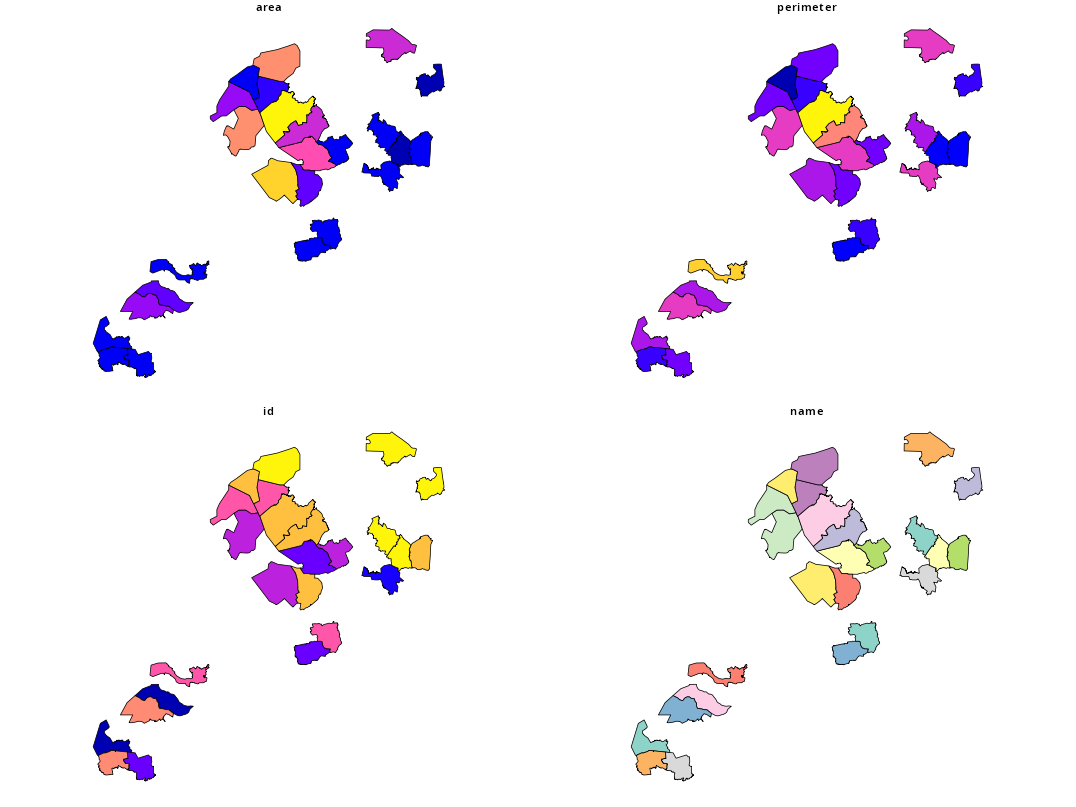

In [146]:
myres_sf <- myres |>
  toJSON(auto_unbox = TRUE) |>
  geojson_sf()
plot(myres_sf)

### 7.2. Return all region boundaries based on postal codes

In [147]:
myurl <- adc_url(option = "Postalcodes",
                 params = c(output_epsg = "4326",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/regions/postalcodes?output_epsg=4326&page_size=25&page_offset=0

In [148]:
myres <- adc_get(url = myurl, token = mytoken)
myres_df <- myres |>
    toJSON() |>
    fromJSON(simplifyDataFrame = TRUE)
cat("Dimensions:",
    nrow(myres_df$features$properties), "rows x",
    ncol(myres_df$features$properties), "columns")

Dimensions: 25 rows x 4 columns

In [149]:
myres_df$features$properties |>
  head(10) |>
  print()

        area perimeter     id postcode
1  410441715  91088.11 403343   8244PB
2  403366190  108552.2 454964   9979XX
3  319397224  88601.67 419369   8862NZ
4  250510474  85933.01 419737   8897HE
5  227928195  91628.78 402946   8242PZ
6  206176550  95990.57 419622   8881HG
7  196153766  96987.47 419793   8899ZN
8  177849968  60418.74  57349   1792CB
9  113311385  55795.59 426524   9166SL
10 110816644  50904.43 426183   9161AS


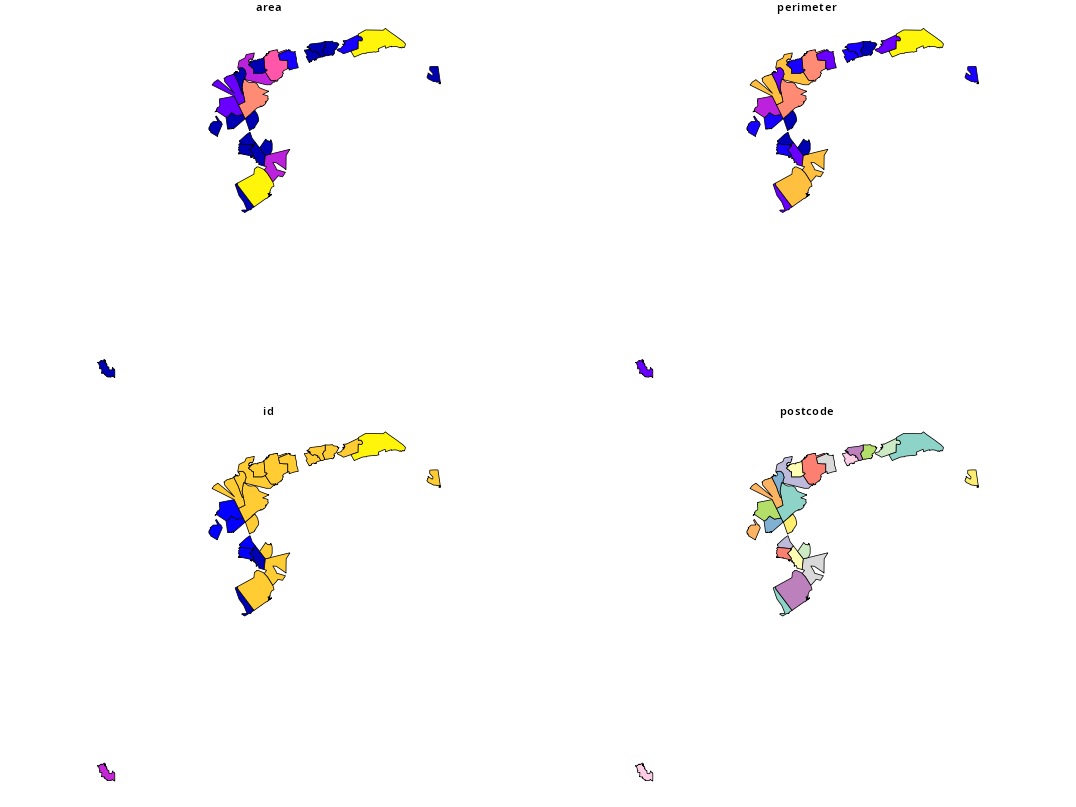

In [150]:
myres_sf <- myres |>
  toJSON(auto_unbox = TRUE) |>
  geojson_sf()
plot(myres_sf)

### 7.3. Return all region boundaries based on provinces

In [151]:
myurl <- adc_url(option = "Provinces",
                 params = c(output_epsg = "4326",
                            page_size = "25",
                            page_offset = "0"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/regions/provinces?output_epsg=4326&page_size=25&page_offset=0

In [152]:
myres <- adc_get(url = myurl, token = mytoken)
myres_df <- myres |>
  toJSON() |>
  fromJSON(simplifyDataFrame = TRUE)
cat("Dimensions:",
    nrow(myres_df$features$properties), "rows x",
    ncol(myres_df$features$properties), "columns")

Dimensions: 12 rows x 4 columns

In [153]:
print(myres_df$features$properties)

         area perimeter id          name
1  5748751544  382644.1  5       Fryslân
2  5136514976  561381.7  3    Gelderland
3  5081754945  518496.7  9 Noord-Brabant
4  4091738584  394724.8 10 Noord-Holland
5  3420863133    425722  8    Overijssel
6  3418526942  347276.4  1  Zuid-Holland
7  2960049439  310841.4 11     Groningen
8  2933893552  264157.4  7       Zeeland
9  2680337505  283716.5 12       Drenthe
10 2412296369  243053.3  4     Flevoland
11 2209221445  463760.4  6       Limburg
12 1449119349  283736.5  2       Utrecht


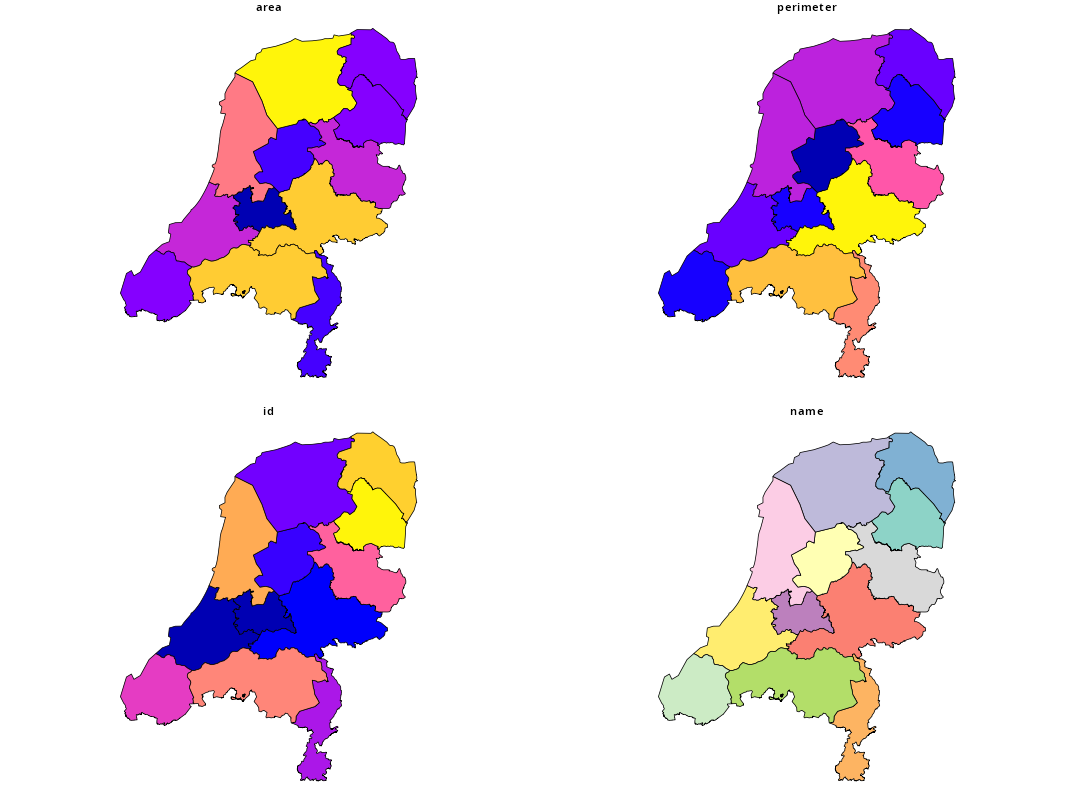

In [154]:
myres_sf <- myres |>
  toJSON(auto_unbox = TRUE) |> 
  geojson_sf()
plot(myres_sf)

## 8. Datapackage

Datapackage has been introduced in summer 2022. A request for a datapackage can return data from different resources for a collection of AgroDataCube fieldids. The format in which data is returned is defined by the datapackage. Currently JSON or GeoJSON are returned.

New requests using datapackages can be added on the fly so it might be possible this documentation is not up to date.

### 8.1. KPI - Greenness

In [155]:
myurl <- adc_url(option = "KPI_Greenness",
                 params = c(fieldids = "9403114"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/datapackage/kpi/greenness?fieldids=9403114

In [156]:
myres <- adc_get(url = myurl, token = mytoken)
myres_sf <- myres |>
  toJSON(auto_unbox = TRUE) |> 
  geojson_sf()

In [157]:
myres_field <- myres_sf$field |>
  fromJSON(simplifyDataFrame = TRUE)
cat("Length:", length(myres_df$features$properties), "values")

Length: 4 values

In [158]:
myres_field |>
  unlist() |>
  as.data.frame() |>
  setNames("value") |>
  print()

                       value
fieldid              9403114
crop_code                265
area              40938.2088
year                    2020
crop_name Grasland, blijvend


In [159]:
myres_ndvi <- myres_sf$ndvi |>
  fromJSON(simplifyDataFrame = TRUE)
cat("Dimensions:",
    nrow(myres_ndvi), "rows x",
    ncol(myres_ndvi), "columns")

Dimensions: 39 rows x 4 columns

In [160]:
myres_ndvi |>
  head(10) |>
  print()

        datum ndvi_avg ndvi_stddev daynr
1  2020-02-05   0.7579      0.0305    36
2  2020-03-23   0.7507      0.0362    83
3  2020-03-26   0.7292      0.0380    86
4  2020-03-31   0.7596      0.0357    91
5  2020-04-05   0.7818      0.0308    96
6  2020-04-07   0.7839      0.0207    98
7  2020-04-15   0.9147      0.0175   106
8  2020-04-17   0.9111      0.0214   108
9  2020-04-19   0.8858      0.0562   110
10 2020-04-20   0.9275      0.0222   111


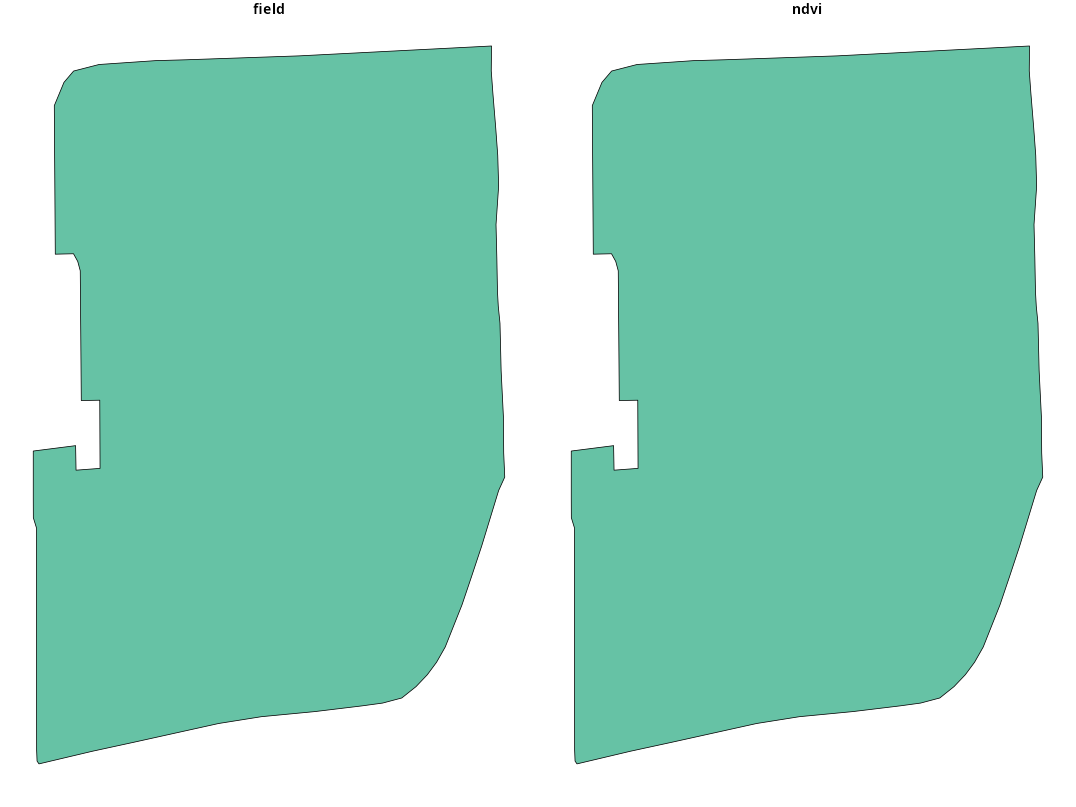

In [161]:
suppressWarnings(plot(myres_sf))

### 8.2. KPI - Croprotation

In [162]:
myurl <- adc_url(option = "KPI_Croprotation",
                 params = c(fieldids = "9403114"))
cat(myurl)

https://agrodatacube.wur.nl/api/v2/rest/datapackage/kpi/croprotation?fieldids=9403114

In [163]:
myres <- adc_get(url = myurl, token = mytoken)
myres_sf <- myres |>
  toJSON(auto_unbox = TRUE) |>
  geojson_sf()

In [164]:
myres_field <- myres_sf$field |>
  fromJSON(simplifyDataFrame = TRUE)
cat("Length:", length(myres_field), "values")

Length: 3 values

In [165]:
myres_field |>
  unlist() |>
  as.data.frame() |>
  setNames("value") |>
  print()

               value
fieldid      9403114
crop_code        265
area      40938.2088


In [166]:
myres_crophistory <- myres_sf$crop_history |>
  fromJSON(simplifyDataFrame = TRUE)
cat("Dimensions:",
    nrow(myres_crophistory), "rows x",
    ncol(myres_crophistory), "columns")

Dimensions: 12 rows x 5 columns

In [167]:
print(myres_crophistory)

   crop_code_in_year year fieldid_in_year intersected_area     area
1                265 2020         9403114         40938.21 40938.21
2                265 2019         9289293         40902.06 41279.96
3                265 2018         8584057         40938.21 41316.10
4                265 2010         1441244         40676.97 42313.72
5                265 2011         2373534         40677.01 42317.87
6                265 2012         2502970         40855.59 42359.02
7                265 2013         3651395         40855.59 42359.02
8                265 2014         4663439         40855.59 42359.02
9                265 2015         5142822         40855.59 42359.02
10               265 2016         6180491         40317.46 40695.40
11               265 2017         6810188         40938.21 41316.10
12               265 2009          100549         40094.51 41749.21


In [168]:
myres_cropinformation <- myres_sf$cropinformation |>
  fromJSON(simplifyDataFrame = TRUE)
cat("Length:", length(myres_cropinformation), "values")

Length: 7 values

In [169]:
myres_cropinformation |>
  unlist() |>
  as.data.frame() |>
  setNames("value") |>
  print()

                              value
cropcode                        265
cropname         Grasland, blijvend
grondgebruik               Grasland
cropid                          209
conflict                      FALSE
standard_revenue               1250


In [170]:
myres_croprotationindex <- myres_sf$croprotationindex |>
  fromJSON(simplifyDataFrame = TRUE)
cat("Length:", length(myres_croprotationindex), "values")

Length: 3 values

In [171]:
myres_croprotationindex |>
  unlist() |>
  as.data.frame() |>
  setNames("value") |>
  print()

           value
fieldid  9403114
index          1
numyears       6


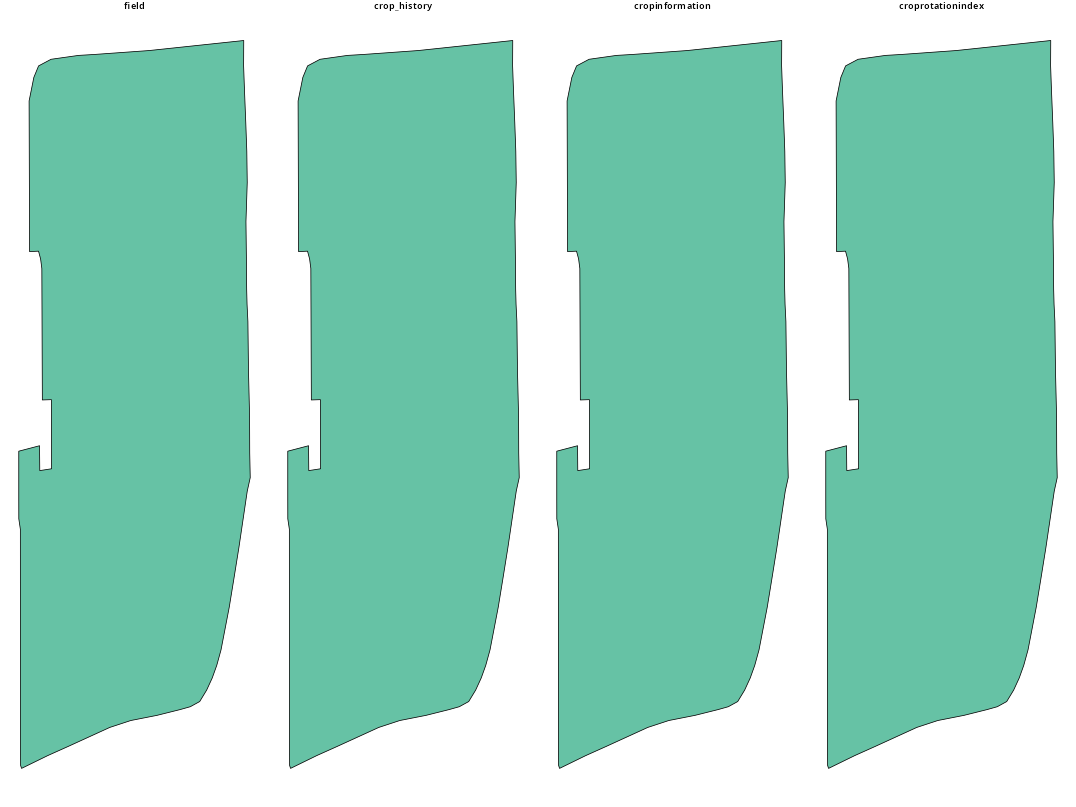

In [172]:
suppressWarnings(plot(myres_sf))